In [6]:
import pandas as pd
import numpy as np
import random
import os
import re
import warnings
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier  # XGBoost 대신 Gradient Boosting을 임포트합니다.
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

CSV_PATH = '/Users/woojin/Desktop/복분자/BukBunJa_GraduationWork/server/data/lotto_data_for_db.csv'
assert os.path.exists(CSV_PATH), f'CSV 파일을 찾을 수 없습니다: {CSV_PATH}'

df = pd.read_csv(CSV_PATH)
df

,년도,회차,추첨일,1등_당첨자수,1등_당첨금액,2등_당첨자수,2등_당첨금액,3등_당첨자수,3등_당첨금액,4등_당첨자수,4등_당첨금액,5등_당첨자수,5등_당첨금액,당첨번호_1,당첨번호_2,당첨번호_3,당첨번호_4,당첨번호_5,당첨번호_6,보너스번호
0,2025,1190,20250920,6,4622793813,113,40909680,3293,1403825,168764,50000,2752776,5000,7,9,19,23,26,45,33
1,2025,1189,20250913,13,2263651299,167,29368730,3121,1571477,152345,50000,2577694,5000,9,19,29,35,37,38,31
2,2025,1188,20250906,24,1074625172,111,38725232,3713,1157690,188314,50000,2901056,5000,3,4,12,19,22,27,9
3,2025,1187,20250830,11,2619380012,79,60787300,3147,1525961,152448,50000,2557090,5000,5,13,26,29,37,40,42
4,2025,1186,20250823,14,1985676911,89,52058946,3226,1436221,162707,50000,2628810,5000,2,8,13,16,23,28,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,2003,5,20030104,0,0,0,0,42,6033800,3043,166500,60434,10000,16,24,29,40,41,42,3
1186,2002,4,20021228,0,0,1,211191200,29,7282400,2777,152100,52382,10000,14,27,30,31,40,42,2
1187,2002,3,20021221,1,2000000000,0,0,139,1174100,5940,54900,73256,10000,11,16,19,21,27,31,30
1188,2002,2,20021214,1,2002006800,2,94866800,103,1842000,3763,100800,55480,10000,9,13,21,25,32,42,2


In [7]:
def find_number_columns_kor(df_):
    cols = list(df_.columns)
    cand = [f'당첨번호_{i}' for i in range(1, 7)]
    if all(c in cols for c in cand):
        return cand
    pattern_cols = [c for c in cols if re.search(r'당첨.?번호', str(c)) and '보너' not in str(c)]
    if pattern_cols:
        def trailing_num(name):
            m = re.search(r'(\d+)$', str(name))
            return int(m.group(1)) if m else 999
        pattern_cols.sort(key=trailing_num)
        if len(pattern_cols) >= 6:
            return pattern_cols[:6]
    lower = {str(c).lower(): c for c in cols}
    for base in ['drwtno', 'n', 'no', 'num', 'ball', 'col']:
        trial = []
        ok = True
        for i in range(1, 7):
            key = f'{base}{i}'
            if key in lower:
                trial.append(lower[key])
            else:
                ok = False
                break
        if ok:
            return trial
    numlike = []
    for c in cols:
        s = pd.to_numeric(df_[c], errors='coerce')
        if s.notna().mean() < 0.7:
            continue
        rng = ((s >= 1) & (s <= 45)).mean()
        if rng > 0.7:
            numlike.append((c, rng))
    numlike.sort(key=lambda x: x[1], reverse=True)
    if len(numlike) >= 6:
        return [c for c, _ in numlike[:6]]
    raise ValueError(f"당첨번호 6개 컬럼 탐지 실패. 현재 컬럼: {list(df_.columns)}")

num_cols = find_number_columns_kor(df)

# 숫자 변환, 1~45 필터링 및 정렬
nums = df[num_cols].apply(pd.to_numeric, errors='coerce').dropna()
mask = nums.applymap(lambda x: 1 <= x <= 45).all(axis=1)
nums = nums[mask]
draws = nums.apply(lambda r: sorted(map(int, r.values)), axis=1, result_type='expand')
draws.columns = ['n1', 'n2', 'n3', 'n4', 'n5', 'n6']
print("데이터 전처리 후 처음 5개 행:")
print(draws.head())
print("-" * 30)

데이터 전처리 후 처음 5개 행:
   n1  n2  n3  n4  n5  n6
0   7   9  19  23  26  45
1   9  19  29  35  37  38
2   3   4  12  19  22  27
3   5  13  26  29  37  40
4   2   8  13  16  23  28
------------------------------


In [8]:
def primes_upto(n=45):
    sieve = [True] * (n + 1)
    sieve[0] = sieve[1] = False
    for i in range(2, int(n**0.5) + 1):
        if sieve[i]:
            for j in range(i * i, n + 1, i):
                sieve[j] = False
    return {i for i, v in enumerate(sieve) if v}

PRIMES = primes_upto(45)

def corpus_stats(df_draws):
    freq = np.zeros(46)
    last_seen = np.zeros(46) + 9999
    for _, row in df_draws.reset_index(drop=True).iterrows():
        for x in row.values:
            x = int(x)
            freq[x] += 1
            last_seen[x] = 0
        last_seen[last_seen < 9999] += 1
    freq = (freq - freq.mean()) / (freq.std() + 1e-6)
    last_seen = (last_seen - last_seen.mean()) / (last_seen.std() + 1e-6)
    return freq, last_seen

def combo_features(arr, freq, last_seen):
    arr = np.array(arr, dtype=int)
    odds = int(np.sum(arr % 2 == 1))
    total = int(np.sum(arr))
    spread = int(arr[-1] - arr[0])
    consec = int(np.sum(np.diff(arr) == 1))
    low_cnt = int(np.sum(arr <= 22))
    primes = int(np.sum(np.isin(arr, list(PRIMES))))
    freq_sum = float(np.sum(freq[arr]))
    recency = float(np.sum(last_seen[arr]))
    return [odds, total, spread, consec, low_cnt, primes, freq_sum, recency]


In [9]:
freq, last_seen = corpus_stats(draws)

# 긍정 샘플 (실제 당첨 번호)
X_pos = [combo_features(np.sort(r.values), freq, last_seen) for _, r in draws.iterrows()]
y_pos = np.ones(len(X_pos), dtype=int)

# 부정 샘플 (랜덤 조합)
win_set = {tuple(sorted(map(int, r.values))) for _, r in draws.iterrows()}
def rand_combo():
    return tuple(sorted(random.sample(range(1, 46), 6)))

X_neg = []
while len(X_neg) < len(X_pos) * 10:
    c = rand_combo()
    if c in win_set:
        continue
    X_neg.append(combo_features(np.array(c), freq, last_seen))
y_neg = np.zeros(len(X_neg), dtype=int)

X = np.array(X_pos + X_neg, dtype=float)
y = np.concatenate([y_pos, y_neg])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# XGBClassifier를 GradientBoostingClassifier로 변경
model = GradientBoostingClassifier(
    n_estimators=220,
    max_depth=5,
    learning_rate=0.09,
    subsample=0.9,
    max_features=0.8,  # colsample_bytree와 유사한 기능
    random_state=42
)

model.fit(X_train, y_train)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print("검증 AUC:", round(auc, 3))
print("-" * 30)

검증 AUC: 0.492
------------------------------


In [10]:
weights = {
    "freq": 0.6,
    "odd_even": 0.5,
    "sum": 0.5,
    "spread": 0.3,
    "consec": 0.4,
    "low_high": 0.4,
    "recency": 0.3
}

def gen_candidates(k, w, freq, last_seen):
    def weight_score(arr):
        f = combo_features(arr, freq, last_seen)
        score = 0.0
        score += w["freq"] * f[6]
        score -= w["odd_even"] * abs(f[0] - 3)
        if f[1] < 100:
            score -= w["sum"] * (100 - f[1]) / 10
        if f[1] > 170:
            score -= w["sum"] * (f[1] - 170) / 10
        score -= w["consec"] * f[3]
        score -= w["low_high"] * abs(f[4] - 3)
        score += w["recency"] * f[7]
        score += w["spread"] * (f[2] / 44.0)
        return score
    
    seen = set()
    out = []
    while len(out) < k:
        c = tuple(sorted(random.sample(range(1, 46), 6)))
        if c in seen:
            continue
        seen.add(c)
        out.append((c, weight_score(c)))
    
    out.sort(key=lambda x: x[1], reverse=True)
    return [c for c, _ in out]

random.seed(42)

K = 2000   # 후보 조합 수
TOPN = 20  # 상위 출력 개수

cand = gen_candidates(K, weights, freq, last_seen)
feats = [combo_features(np.array(c), freq, last_seen) for c in cand]
probs = model.predict_proba(np.array(feats))[:, 1]
ranked = sorted(zip(cand, probs), key=lambda x: x[1], reverse=True)[:TOPN]

# 최종 추천 번호 선택 (상위 N개 중 랜덤 선택)
pick = random.choice(ranked)
c, p = pick
final_nums_str = ' '.join(map(str, c))

print("--- 최종 추천 번호 ---")
for idx, (c, p) in enumerate(ranked, start=1):
    nums = ' '.join(map(str, c))
    print(f"후보 {idx:02}: {nums} (모델 점수={p:.6f})")

print(f"\n✨ 최종 추천: {final_nums_str} (모델 점수={p:.6f})")
print("-" * 30)

--- 최종 추천 번호 ---
후보 01: 3 4 11 13 17 19 (모델 점수=0.979950)
후보 02: 2 7 11 13 14 19 (모델 점수=0.775422)
후보 03: 10 32 34 36 40 44 (모델 점수=0.696494)
후보 04: 10 13 33 34 37 39 (모델 점수=0.668432)
후보 05: 13 17 21 26 27 40 (모델 점수=0.661385)
후보 06: 6 16 26 28 34 38 (모델 점수=0.642164)
후보 07: 5 7 9 15 25 43 (모델 점수=0.540484)
후보 08: 13 34 36 37 40 42 (모델 점수=0.476675)
후보 09: 13 14 15 16 26 29 (모델 점수=0.467054)
후보 10: 1 7 12 15 28 42 (모델 점수=0.455139)
후보 11: 15 27 34 39 40 44 (모델 점수=0.433090)
후보 12: 1 32 35 39 44 45 (모델 점수=0.407194)
후보 13: 32 35 41 43 44 45 (모델 점수=0.389862)
후보 14: 15 30 31 41 42 44 (모델 점수=0.386983)
후보 15: 20 25 33 35 38 43 (모델 점수=0.375055)
후보 16: 2 4 5 7 9 41 (모델 점수=0.374983)
후보 17: 11 15 27 31 39 45 (모델 점수=0.373755)
후보 18: 11 13 17 20 28 44 (모델 점수=0.373092)
후보 19: 2 24 27 30 34 45 (모델 점수=0.346670)
후보 20: 9 23 27 31 35 44 (모델 점수=0.343863)

✨ 최종 추천: 2 4 5 7 9 41 (모델 점수=0.343863)
------------------------------


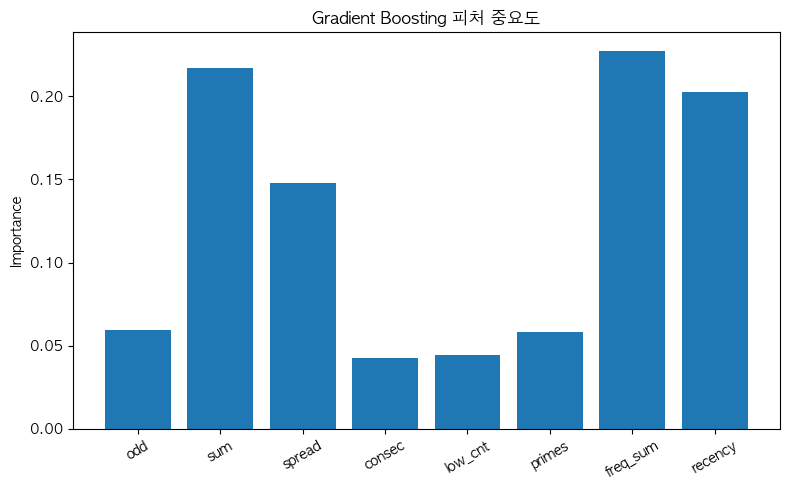

In [11]:
importances = model.feature_importances_
names = ["odd", "sum", "spread", "consec", "low_cnt", "primes", "freq_sum", "recency"]

plt.rc('font', family='AppleGothic')
plt.figure(figsize=(8, 5))
plt.bar(names, importances)
plt.xticks(rotation=30)
plt.title("Gradient Boosting 피처 중요도")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()